# Signal Acquisition and Synchronization

In realistic digital communication systems, several signal parameters are unknown, including
* signal amplitude $A$
* carrier phase $\phi$
* carrier frequency offset $\Delta f$
* signal delay $\tau$

The receiver can **not** recover the information symbols without knowing and correcting for these unknow signal parameters.

The unknown signal parameters must be measured (estimated) from the received signal. Usually, this is accomplished by sending a training sequence of known symbols before the information bearing signal.

Signal parameters are determined from this training sequence and are then used to enable the transmitter to receive the information symbols.

Today, we show how the training sequence can be leveraged to learn where in the received stream of samples the signal starts. Armed with that information, we will estimate the amplitude and phase. Initial estimation of the frequency offset will be discussed later.


In [1]:
## Boilerplate instructions for importing NumPy and Matplotlib
# Import NumPy
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns_context = "notebook"
sns.set_theme(context=sns_context, style="ticks")

# proper labeling of plots
from matplotlib.ticker import EngFormatter

In [5]:
from dc_632_26.sources import RandomBitSource
from dc_632_26.pulses import CosineSquaredPulse
from dc_632_26.constellations import standard_constellation
from dc_632_26.modulation import modulation
from dc_632_26.pulse_shaper import PulseShaper

# Constructing the Training Sequence

We begin by creating a "naive" training sequence consisting of known symbols that will be used to estimate the unknown signal parameters. Better training sequences will be introduced later.

Our training sequence will consist of known symbols, which allows the receiver to correlate the received signal with the expected pattern and determine the start of the signal.

These training symbols are pulse-shaped just like information symbols - the only difference is that their values are known a priori to the receiver.

We will transmit only the training sequence initially, allowing the receiver to synchronize and estimate the channel before sending actual information symbols.

In [25]:
# make a training sequence
K = 32      # length of training sequence
constellation = standard_constellation.BPSK
fsT = 32
pulse = CosineSquaredPulse(fsT)
ps = PulseShaper(pulse, fsT)

training_bits = RandomBitSource().get_bits(K)
training_symbols = modulation(training_bits, constellation)
training_sig = ps.generate_waveform(training_symbols)



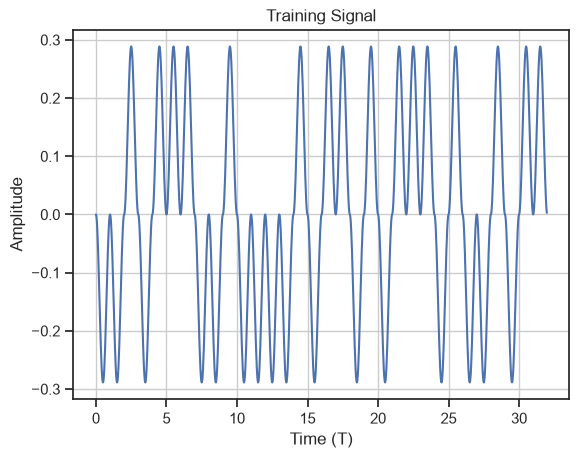

In [26]:
plt.plot(np.arange(len(training_sig))/fsT, training_sig.real)
plt.xlabel('Time (T)')
plt.ylabel('Amplitude')
plt.title('Training Signal')
plt.grid(True)
plt.show()

## Simulating transmission

Our simulated transmission will include:

* AWGN
* a delay of 102 samples
* amplitude and phase change
* reduction of the sample rate from 32 to 8; note that 102 is not evenly divisible by 8 so that we incur a fractional delay
* frequency offset is not simulated at this time

In [ ]:
## channel parameters
delay_samples = 102
ds_factor = 4       # down-sample by 4
fsT_r = fsT // ds_factor

# frequency offset per symbol period, phase change is 0.1*2*pi over course of preamble
df = 0. # no frequency offset at this time 
X = 0.5*np.exp(1j*np.pi/4) # amplitude and phase

# delay by pre-pending zeros
rr = np.concatenate(( np.zeros(delay_samples), 
                     X * training_sig * np.exp(2j * np.pi * df * np.arange(len(training_sig))), 
                     np.zeros(delay_samples) ))

# down-sample
rr = rr[::ds_factor]
fsT_r = fsT // ds_factor

SNR_dB = 20
SNR = 10**(SNR_dB/10)
noise_var = constellation.Es / SNR 

## the down-sampled signal amplitude is increased, to compensate for "energy" lost
# when discarding samples
rr = np.sqrt(ds_factor)*rr + np.sqrt(0.5 * noise_var) * (np.random.randn(len(rr)) + 1j*np.random.randn(len(rr))) 

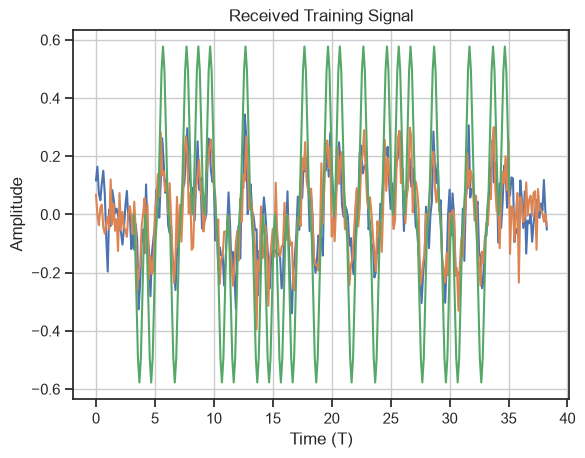

In [66]:
plt.plot(np.arange(len(rr))/fsT_r, rr.real, label="In-phase")
plt.plot(np.arange(len(rr))/fsT_r, rr.imag, label="Quadrature")
plt.plot(np.arange((len(ref_signal)))/fsT_r+delay_samples/fsT, 
         ref_signal.real, label="Reference In-phase")

plt.xlabel('Time (T)')
plt.ylabel('Amplitude')
plt.title('Received Training Signal')
plt.grid(True)
plt.show()

In [ ]:
# training signal at the down-sampled rate
pulse_r = CosineSquaredPulse(fsT_r)
ps_r = PulseShaper(pulse_r, fsT_r)
ref_signal = ps_r.generate_waveform(training_symbols)

Maximum correlation at lag: 25 samples


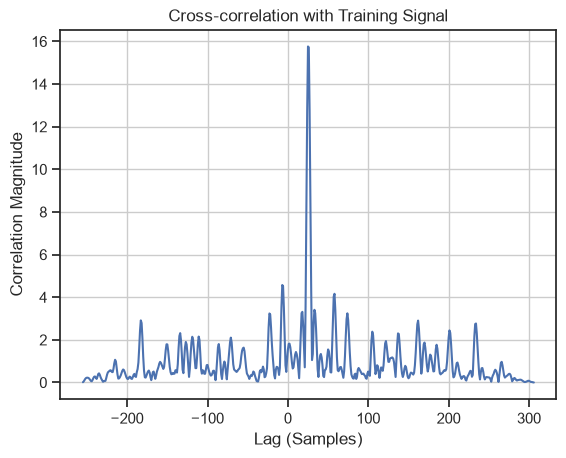

In [67]:
r_corr = np.correlate(rr, ref_signal, mode='full')

n_samples = np.arange(len(r_corr))-(len(ref_signal)-1)
plt.plot(n_samples, np.abs(r_corr))
plt.xlabel('Lag (Samples)')
plt.ylabel('Correlation Magnitude')
plt.title('Cross-correlation with Training Signal')
plt.grid(True)

n_max = np.argmax(np.abs(r_corr))
lag_max = n_samples[n_max]
print(f"Maximum correlation at lag: {lag_max} samples")
plt.show()


In [77]:
# complex amplitude at the correlation peak:
r_peak = r_corr[n_max]
print(f"Magnitude at the correlation peak: {np.abs(r_peak)/np.linalg.norm(ref_signal)**2}")
print(f"Phase at the correlation peak: {np.angle(r_peak)/np.pi}*pi")

Magnitude at the correlation peak: 0.4925432785037075
Phase at the correlation peak: 0.2479596163109657*pi


* The correlation peak occurs at lag 25 samples, which corresponds to a time delay of 25/8 = 3.125 symbol periods (at the down-sampled rate of 8 samples per symbol).
* The true delay was 102 samples, which corresponds to a time delay of 102/32 = 3.1875 symbol periods (at the transmitted rate of 32 samples per symbol).
  - note that 3/16 ≈ is not an integer multiple of 1/8, i.e., the true delay lies between 25 and 26 received samples
* the estimated complex amplitude is very close to the true complex amplitude.


## Using a matched filter

We can use a matched filter to detect the presence of the training signal in the received signal. 

1. pass the received signal through a matched filter (for the received sample rate).
2. divide the matched filter output into 8 sample phases
3. correlate each phase with the reference training symbol sequence.
4. identify the phase with the maximum correlation peak as the estimated timing offset.

In [88]:
mf = pulse_r.samples
# matched filter
mf_out = np.convolve(rr, mf)

# divide the matched filter output into 8 sample phases
L = len(mf_out) // fsT_r
phases = np.array([mf_out[i:L*fsT_r:fsT_r] for i in range(fsT_r)])

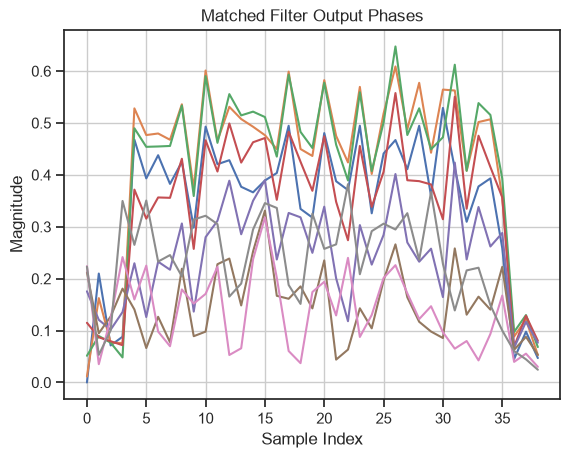

In [89]:
# what do the different phases of the matched filter output look like?
plt.plot(np.arange(L), np.abs(phases.T))
plt.title("Matched Filter Output Phases")
plt.xlabel("Sample Index")
plt.ylabel("Magnitude")
plt.grid(True)


### Which of these phases correlates best with the reference sequence? 

To determine that, pass the each phase through a "symbol mateched filter", i.e., convolve with the time reversed reference training symbol sequence.

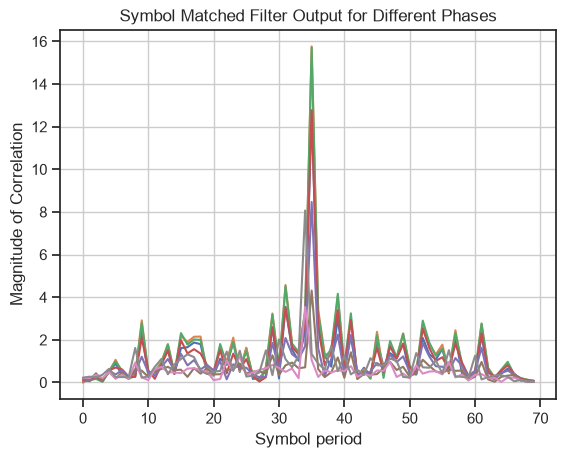

Phase 0: Max correlation = 12.74208357918284 at sample 35
Phase 1: Max correlation = 15.761384912118638 at sample 35
Phase 2: Max correlation = 15.717053054609012 at sample 35
Phase 3: Max correlation = 12.765552703444813 at sample 35
Phase 4: Max correlation = 8.468042060789605 at sample 35
Phase 5: Max correlation = 4.311185692429743 at sample 35
Phase 6: Max correlation = 3.5453157140732046 at sample 34
Phase 7: Max correlation = 8.067095950103235 at sample 34


In [93]:
dd = np.array([np.convolve(phases[i, :], training_symbols[::-1]) for i in range(fsT_r)])

plt.plot(np.arange(L+len(training_symbols)-1), np.abs(dd.T))
plt.title("Symbol Matched Filter Output for Different Phases")
plt.xlabel("Symbol period")
plt.ylabel("Magnitude of Correlation")
plt.grid(True)
plt.show()

for i in range(fsT_r):
    print(f"Phase {i}: Max correlation = {np.max(np.abs(dd[i, :]))} at sample {np.argmax(np.abs(dd[i, :]))}")


So the maximum correlation occurs for:
* sampling phase: i=1 (closely followed by i=2)
* in period n = 35. 

Is this right?


The original delay was 102 samples at the transmit sample rate of 32 samples per symbol period T.
This corresponds to a delay of 102 / 32 = 3.1875 symbol periods.

In the receiver, the following filter delays are incurred:
* Matched filter delay: `fsT_r-1` samples at rate 8 samples per symbol period(to make filter causal)
    - an additional delay of 1 sample at rate of 8 samples per symbol period is incurred because the best sampling phase occurs in the next symbol period
* Symbol matched filter delay: 31 samples at rate 1 sample per symbol period (to make filter causal)
    - length of the training sequence - 1

Thus, the total filter delay in the receiver until the maximum output is: 1 + 31 = 32 symbol periods.

The sum of this total filter delay in the receiver and the original delay at the transmitter is: 32 + 3.1875 = 35.1875 symbol periods.

The measured delay is 35 symbol periods + 1/8 symbol period (i=1) = 35.125 symbol periods.

**Conclusion:** The best sampling phase is phase i=1 and the last sample of the training sequence is in symbol period 35.

The magnitude of the corresponding correlator output reflects the complex magnitude of the channel.

In [101]:
A = dd[1, 35] / (np.linalg.norm(ref_signal)**2)

print(f'complex magnitude: {np.abs(A):.4f} exp(1j * {np.angle(A)/np.pi:.4f}*pi)')

complex magnitude: 0.4925 exp(1j * 0.2480*pi)


The estimated complex amplitude is close to the true complex amplitude $0.5e^{j\pi/4}$ of the channel.

## Next Steps

To make this practical, we need to address the following questions:

* How should the preamble sequence be chosen?
* What is a good value for the detection threshold?
* What modifications are needed to cope with a frequency offset between transmitter and receiver?
* What logic is needed in the transmitter and receiver to switch from preamble processing to data transmission?